# **Hardware Accelerators – Spring 2025**
## **Homework 2 (Digits Classification)**


## **NIST Dataset**
We are using the load_digits dataset from scikit-learn. This dataset is similar to MNIST but smaller. It is known as **the NIST dataset**, a reduced version of MNIST. It contains 1,797 grayscale images, each of size 8×8 pixels, with pixel values represented as positive integers.


---




You can find more details in the [official scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html).

> **Note**: The raw and preprocessed dataset is provided in the HW directory.

In [ ]:
from sklearn.datasets import load_digits

### **Preprocessing**
We need to load the dataset, encode the labels, split the data into training and testing sets, and finally, standardize the feature values. You can use print statements to observe how the values change after each preprocessing step.

> **Note**: Some preprocessing steps need to be applied to the dataset before reading the data in your HDL implementation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# load NIST
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # flatten 8x8 to 64
y = digits.target.reshape(-1, 1)

# encode labels
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# split datasets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Model**
We are building a neural network to classify 10 digits. The model will be a Multilayer Perceptron (MLP) with:

- Input size: 64 (corresponding to the 8×8 image pixels)
- Hidden layer size: 256
- Output size: 10 (one for each digit class)

In short, the architecture is (64, 256, 10).

### **Training**
To test the MLP architecture, we use TensorFlow for quick training. We build an MLP with:

- Input size: 64
- Hidden layer size: 256
- Output layer size: 10

This allows us to validate the network structure before further implementation.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(256, activation='relu', input_shape=(64,)),  # Hidden Layer with 256 neurons
    Dense(10, activation='softmax')  # Output Layer with 10 neurons (one per class)
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5079 - loss: 1.6353 - val_accuracy: 0.9167 - val_loss: 0.5007
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9283 - loss: 0.4053 - val_accuracy: 0.9528 - val_loss: 0.2577
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9641 - loss: 0.1927 - val_accuracy: 0.9639 - val_loss: 0.1774
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9761 - loss: 0.1399 - val_accuracy: 0.9639 - val_loss: 0.1401
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9911 - loss: 0.0921 - val_accuracy: 0.9667 - val_loss: 0.1208
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9955 - loss: 0.0695 - val_accuracy: 0.9694 - val_loss: 0.1075
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9957 - loss: 0.0543 - val_accuracy: 0.9750 - val_loss: 0.0970
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9973 - loss: 0.0443 - val_accuracy: 0.9750 - val_loss: 0.0908


### **Evaluation**
We use the test data to calculate the loss and accuracy of the model

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9817 - loss: 0.0591 
Test Accuracy: 0.9778


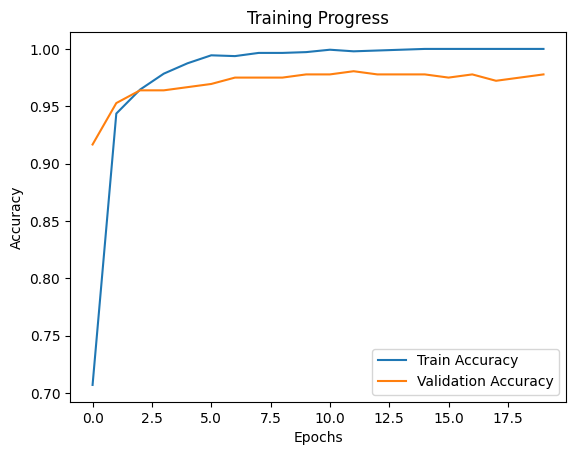

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Progress')
plt.show()

### **Visualization**
We use the predict function along with argmax (to select the highest probability among the 10 classes) to obtain the model's prediction for a specific data sample.

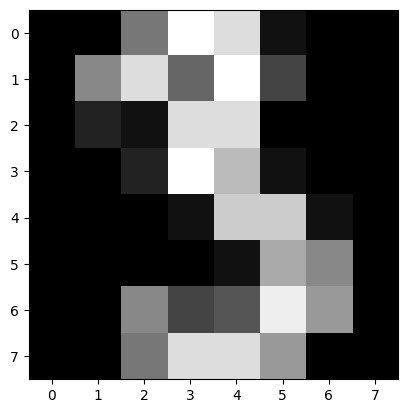

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3


In [ ]:
plt.imshow(digits.images[3], cmap="gray")
plt.show()
res = model.predict(digits.images[3].reshape(1, -1), batch_size=1)
print(np.argmax(res))